# 📌 Inhaltsverzeichnis (TOC)

1. [📥 Datenimport und Überblick](#1-datenimport-und-überblick)
2. [🧹 Datenbereinigung](#2-datenbereinigung)
3. [🧪 Feature Engineering](#3-feature-engineering)
4. [📊 Explorative Datenanalyse (EDA)](#4-explorative-datenanalyse-eda)
5. [🤖 Modellierung (Baseline & Fair)](#5-modellierung)
6. [🌍 Geodatenanalyse](#6-geodatenanalyse)
7. [🗓️ Kalenderdaten](#7-kalenderdaten)
8. [📝 NLP & Sentiment-Analyse (Reviews & TF-IDF)](#8-nlp-sentiment-analyse-reviews-tf-idf)
9. [🖼️ Bildbasierte Features (CNN)](#9-bildbasierte-features-cnn)
10. [📈 Modellvergleich & Hyperparameter-Tuning](#10-modellvergleich-hyperparameter-tuning)
11. [🔎 Fehleranalyse (Residuals)](#11-fehleranalyse-residuals)
12. [🏆 Finales Multi-Modal Modell & Auswertung](#12-finales-multi-modal-modell)

In [1]:
# 1. Setup & Installationen (Einmalig ausführen)
!pip install "numpy<2.0" geopy folium textblob torch torchvision pillow tqdm scikit-learn seaborn

# 2. Standard-Bibliotheken
import os
import warnings

# 3. Datenverarbeitung & Mathematik
import numpy as np
import pandas as pd

# 4. Visualisierung & Geodaten
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import MarkerCluster
from geopy.distance import geodesic

# 5. Machine Learning (Scikit-Learn)
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline

# 6. NLP & Deep Learning (Bilder)
import nltk
from textblob import TextBlob
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision.models import ResNet50_Weights
from PIL import Image
from tqdm import tqdm
from IPython.display import display

# Warnungen unterdrücken
warnings.filterwarnings('ignore')
nltk.download('punkt', quiet=True)
LEAKAGE_COLUMNS = [
    "price", "log_price", "price_per_person",
    "estimated_revenue_l365d", "avg_price_last_365d",
    "estimated_occupancy_l365d",
]

  Using cached numpy-1.26.4-cp313-cp313-linux_x86_64.whl
  Using cached geopy-2.4.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached textblob-0.20.0-py3-none-any.whl.metadata (4.0 kB)
  Using cached geographiclib-2.1-py3-none-any.whl.metadata (1.6 kB)
  Using cached nltk-3.9.4-py3-none-any.whl.metadata (3.2 kB)
  Using cached regex-2026.5.9-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (40 kB)
Using cached geopy-2.4.1-py3-none-any.whl (125 kB)
Using cached geographiclib-2.1-py3-none-any.whl (40 kB)
Using cached textblob-0.20.0-py3-none-any.whl (624 kB)
Using cached nltk-3.9.4-py3-none-any.whl (1.6 MB)
Using cached regex-2026.5.9-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl (801 kB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.3.5
    Uninstalling numpy-2.3.5:
      Successfully uninstalled numpy-2.3.5━━━━━━━━━━━━━━━━━━━━━━━━ 1/6 [numpy]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

## 1. 📥 Datenimport und Überblick

In [2]:
# Lade die Datei
df = pd.read_csv("Data/listings.csv.gz")

# Überblick verschaffen
print(f"Datensatz Shape: {df.shape}")
display(df.head())

# Übersicht über fehlende Werte
missing = df.isnull().sum().sort_values(ascending=False)
print("\nFehlende Werte (Top 15):")
print(missing[missing > 0].head(15))

Datensatz Shape: (13945, 79)


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,3176,https://www.airbnb.com/rooms/3176,20250315152850,2025-03-16,city scrape,Fabulous Flat in great Location,This beautiful first floor apartment is situa...,The neighbourhood is famous for its variety of...,https://a0.muscache.com/pictures/airflow/Hosti...,3718,...,4.70,4.92,4.61,First name and Last name: Nicolas Krotz <br/> ...,f,1,1,0,0,0.78
1,9991,https://www.airbnb.com/rooms/9991,20250315152850,2025-03-16,city scrape,Geourgeous flat - outstanding views,4 bedroom with very large windows and outstand...,Prenzlauer Berg is an amazing neighbourhood wh...,https://a0.muscache.com/pictures/42799131/59c8...,33852,...,5.00,4.86,4.86,03/Z/RA/003410-18,f,1,1,0,0,0.06
2,14325,https://www.airbnb.com/rooms/14325,20250315152850,2025-03-16,city scrape,Studio Apartment in Prenzlauer Berg,The apartment is located on the upper second f...,NaN,https://a0.muscache.com/pictures/508703/24988a...,55531,...,4.85,4.60,4.45,NaN,f,4,4,0,0,0.15
3,16644,https://www.airbnb.com/rooms/16644,20250315152850,2025-03-16,city scrape,In the Heart of Berlin - Kreuzberg,Light and sunny 2-Room-turn of the century-fla...,Our Part of Kreuzberg is just the best. Good v...,https://a0.muscache.com/pictures/73759174/e2ef...,64696,...,4.86,4.67,4.71,NaN,f,2,2,0,0,0.27
4,17904,https://www.airbnb.com/rooms/17904,20250315152850,2025-03-16,city scrape,Beautiful Kreuzberg studio - 3 months minimum,"- apt is available starting September 1, 2024<...","The apartment is located in Kreuzberg, which i...",https://a0.muscache.com/pictures/d9a6f8be-54b9...,68997,...,4.92,4.87,4.65,NaN,f,1,1,0,0,1.63



Fehlende Werte (Top 15):
calendar_updated           13945
host_neighbourhood          7978
neighborhood_overview       7333
neighbourhood               7333
host_about                  6704
host_response_rate          5138
host_response_time          5138
beds                        5056
price                       5047
estimated_revenue_l365d     5047
bathrooms                   5028
license                     5025
host_acceptance_rate        4378
review_scores_value         3319
review_scores_location      3317
dtype: int64


## 2. 🧹 Datenbereinigung
In diesem Schritt entfernen wir irrelevante Spalten, behandeln fehlende Werte und korrigieren Datentypen (z.B. den Preis).

In [3]:
# 1. Schwellenwert für Spalten mit zu vielen fehlenden Werten (>50 %)
threshold = len(df) * 0.5
df_clean = df.dropna(thresh=threshold, axis=1).copy()

# 2. Irrelevante Spalten & Host-Infos mit hoher Missing-Rate entfernen
cols_to_drop = [
    'scrape_id', 'last_scraped', 'source', 'host_url', 'host_thumbnail_url', 
    'host_picture_url', 'picture_url', 'calendar_updated', 'calendar_last_scraped', 
    'license', 'host_neighbourhood', 'neighborhood_overview', 'neighbourhood', 
    'host_about', 'host_has_profile_pic', 'host_identity_verified', 'host_id', 
    'host_name', 'host_since', 'host_location', 'host_verifications'
]
df_clean = df_clean.drop(columns=[col for col in cols_to_drop if col in df_clean.columns], errors='ignore')

# 3. Fehlende Werte sinnvoll mit 0 füllen
fill_zero_cols = ['reviews_per_month', 'estimated_revenue_l365d', 'price', 'estimated_occupancy_l365d']
for col in fill_zero_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna(0)

# 4. Datumsfelder korrekt umwandeln
date_cols = ['first_review', 'last_review']
for col in date_cols:
    if col in df_clean.columns:
        df_clean[col] = pd.to_datetime(df_clean[col], errors='coerce')

# 5. Preis-Spalte bereinigen (String "$1,000.00" -> Float 1000.0)
df_clean["price"] = (
    df_clean["price"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

# Optional: Duplikate entfernen
df_clean = df_clean.drop_duplicates()

print("Verbleibende fehlende Werte (Top 5):")
print(df_clean.isnull().sum().sort_values(ascending=False).head(5))

Verbleibende fehlende Werte (Top 5):
host_response_time      5138
host_response_rate      5138
beds                    5056
bathrooms               5028
host_acceptance_rate    4378
dtype: int64


## 3. 🧪 Feature Engineering
Wir reichern den Datensatz mit abgeleiteten Informationen an (z.B. Bezirke, Preis pro Person, etc.).

In [4]:
# Mapping von Lokalitäten zu Bezirken (gekürzt zur Übersichtlichkeit)
lokalitaet_zu_bezirk = {
    # Charlottenburg-Wilmersdorf
    "Albrechtstr.": "Charlottenburg-Wilmersdorf",
    "Charlottenburg Nord": "Charlottenburg-Wilmersdorf",
    "Drakestr.": "Charlottenburg-Wilmersdorf",
    "Düsseldorfer Straße": "Charlottenburg-Wilmersdorf",
    "Forst Grunewald": "Charlottenburg-Wilmersdorf",
    "Grunewald": "Charlottenburg-Wilmersdorf",
    "Halensee": "Charlottenburg-Wilmersdorf",
    "Heerstrasse": "Charlottenburg-Wilmersdorf",
    "Heerstraße Nord": "Charlottenburg-Wilmersdorf",
    "Kantstraße": "Charlottenburg-Wilmersdorf",
    "Kurfürstendamm": "Charlottenburg-Wilmersdorf",
    "Mierendorffplatz": "Charlottenburg-Wilmersdorf",
    "Neue Kantstraße": "Charlottenburg-Wilmersdorf",
    "Otto-Suhr-Allee": "Charlottenburg-Wilmersdorf",
    "Schloß Charlottenburg": "Charlottenburg-Wilmersdorf",
    "Schmargendorf": "Charlottenburg-Wilmersdorf",
    "Volkspark Wilmersdorf": "Charlottenburg-Wilmersdorf",
    "West 1": "Charlottenburg-Wilmersdorf",
    "West 2": "Charlottenburg-Wilmersdorf",
    "West 3": "Charlottenburg-Wilmersdorf",
    "West 4": "Charlottenburg-Wilmersdorf",
    "West 5": "Charlottenburg-Wilmersdorf",
    "Westend": "Charlottenburg-Wilmersdorf",
    "Wiesbadener Straße": "Charlottenburg-Wilmersdorf",
    # Friedrichshain-Kreuzberg
    "Barstraße": "Friedrichshain-Kreuzberg",
    "Frankfurter Allee Nord": "Friedrichshain-Kreuzberg",
    "Frankfurter Allee Süd": "Friedrichshain-Kreuzberg",
    "Frankfurter Allee Süd FK": "Friedrichshain-Kreuzberg",
    "Karl-Marx-Allee-Nord": "Friedrichshain-Kreuzberg",
    "Karl-Marx-Allee-Süd": "Friedrichshain-Kreuzberg",
    "südliche Luisenstadt": "Friedrichshain-Kreuzberg",
    # Lichtenberg
    "Alt-Hohenschönhausen Nord": "Lichtenberg",
    "Alt-Hohenschönhausen Süd": "Lichtenberg",
    "Alt-Lichtenberg": "Lichtenberg",
    "Fennpfuhl": "Lichtenberg",
    "Friedrichsfelde Nord": "Lichtenberg",
    "Friedrichsfelde Süd": "Lichtenberg",
    "Karlshorst": "Lichtenberg",
    "Neu Lichtenberg": "Lichtenberg",
    "Neu-Hohenschönhausen Nord": "Lichtenberg",
    "Neu-Hohenschönhausen Süd": "Lichtenberg",
    "Rummelsburger Bucht": "Lichtenberg",
    # Marzahn-Hellersdorf
    "Altstadt-Kietz": "Marzahn-Hellersdorf",
    "Biesdorf": "Marzahn-Hellersdorf",
    "Hellersdorf-Nord": "Marzahn-Hellersdorf",
    "Hellersdorf-Ost": "Marzahn-Hellersdorf",
    "Hellersdorf-Süd": "Marzahn-Hellersdorf",
    "Kaulsdorf": "Marzahn-Hellersdorf",
    "Mahlsdorf": "Marzahn-Hellersdorf",
    "Marzahn-Mitte": "Marzahn-Hellersdorf",
    "Marzahn-Nord": "Marzahn-Hellersdorf",
    "Marzahn-Süd": "Marzahn-Hellersdorf",
    # Mitte
    "Alexanderplatz": "Mitte",
    "Brunnenstr. Nord": "Mitte",
    "Brunnenstr. Süd": "Mitte",
    "Moabit Ost": "Mitte",
    "Moabit West": "Mitte",
    "Osloer Straße": "Mitte",
    "Regierungsviertel": "Mitte",
    "Südliche Friedrichstadt": "Mitte",
    "Tiergarten Süd": "Mitte",
    "Wedding Zentrum": "Mitte",
    "nördliche Luisenstadt": "Mitte",
    # Neukölln
    "Britz": "Neukölln",
    "Buckow": "Neukölln",
    "Buckow Nord": "Neukölln",
    "Dammvorstadt": "Neukölln",
    "Gropiusstadt": "Neukölln",
    "Köllnische Heide": "Neukölln",
    "Neuköllner Mitte/Zentrum": "Neukölln",
    "Reuterstraße": "Neukölln",
    "Rixdorf": "Neukölln",
    "Rudow": "Neukölln",
    "Schillerpromenade": "Neukölln",
    # Pankow
    "Blankenburg/Heinersdorf/Märchenland": "Pankow",
    "Blankenfelde/Niederschönhausen": "Pankow",
    "Buch": "Pankow",
    "Buchholz": "Pankow",
    "Helmholtzplatz": "Pankow",
    "Karow": "Pankow",
    "Malchow, Wartenberg und Falkenberg": "Pankow",
    "MV 1": "Pankow", "MV 2": "Pankow",
    "Nord 1": "Pankow", "Nord 2": "Pankow",
    "Ost 1": "Pankow", "Ost 2": "Pankow",
    "Pankow Süd": "Pankow",
    "Pankow Zentrum": "Pankow",
    "Parkviertel": "Pankow",
    "Prenzlauer Berg Nord": "Pankow",
    "Prenzlauer Berg Nordwest": "Pankow",
    "Prenzlauer Berg Ost": "Pankow",
    "Prenzlauer Berg Süd": "Pankow",
    "Prenzlauer Berg Südwest": "Pankow",
    "Schönholz/Wilhelmsruh/Rosenthal": "Pankow",
    "Weißensee": "Pankow",
    "Weißensee Ost": "Pankow",
    # Spandau
    "Brunsbütteler Damm": "Spandau",
    "Falkenhagener Feld": "Spandau",
    "Gatow / Kladow": "Spandau",
    "Hakenfelde": "Spandau",
    "Haselhorst": "Spandau",
    "Siemensstadt": "Spandau",
    "Spandau Mitte": "Spandau",
    "Wilhelmstadt": "Spandau",
    # Steglitz-Zehlendorf
    "Lankwitz": "Steglitz-Zehlendorf",
    "Ostpreußendamm": "Steglitz-Zehlendorf",
    "Schloßstr.": "Steglitz-Zehlendorf",
    "Teltower Damm": "Steglitz-Zehlendorf",
    "Zehlendorf Nord": "Steglitz-Zehlendorf",
    "Zehlendorf Südwest": "Steglitz-Zehlendorf",
    # Tempelhof-Schöneberg
    "Friedenau": "Tempelhof-Schöneberg",
    "Lichtenrade": "Tempelhof-Schöneberg",
    "Mariendorf": "Tempelhof-Schöneberg",
    "Marienfelde": "Tempelhof-Schöneberg",
    "Schöneberg-Nord": "Tempelhof-Schöneberg",
    "Schöneberg-Süd": "Tempelhof-Schöneberg",
    "Tempelhof": "Tempelhof-Schöneberg",
    "Tempelhofer Vorstadt": "Tempelhof-Schöneberg",
    # Treptow-Köpenick
    "Adlershof": "Treptow-Köpenick",
    "Allende-Viertel": "Treptow-Köpenick",
    "Alt Treptow": "Treptow-Köpenick",
    "Altglienicke": "Treptow-Köpenick",
    "Baumschulenweg": "Treptow-Köpenick",
    "Bohnsdorf": "Treptow-Köpenick",
    "Friedrichshagen": "Treptow-Köpenick",
    "Grünau": "Treptow-Köpenick",
    "Johannisthal": "Treptow-Köpenick",
    "Köpenick-Nord": "Treptow-Köpenick",
    "Köpenick-Süd": "Treptow-Köpenick",
    "Kölln. Vorstadt/Spindlersf.": "Treptow-Köpenick",
    "Müggelheim": "Treptow-Köpenick",
    "Niederschöneweide": "Treptow-Köpenick",
    "Oberschöneweide": "Treptow-Köpenick",
    "Plänterwald": "Treptow-Köpenick",
    "Rahnsdorf/Hessenwinkel": "Treptow-Köpenick",
    "Schmöckwitz/Karolinenhof/Rauchfangswerder": "Treptow-Köpenick",
}

# Bezirk zuweisen und bereinigen
if "neighbourhood_cleansed" in df_clean.columns:
    df_clean["neighbourhood_cleansed_clean"] = df_clean["neighbourhood_cleansed"].str.strip()
    df_clean["Bezirk"] = df_clean["neighbourhood_cleansed_clean"].map(lokalitaet_zu_bezirk).fillna("Unbekannt")

# Bezirk zuweisen
if "neighbourhood_cleansed" in df_clean.columns:
    df_clean["neighbourhood_cleansed_clean"] = df_clean["neighbourhood_cleansed"].str.strip()
    df_clean["Bezirk"] = df_clean["neighbourhood_cleansed_clean"].map(lokalitaet_zu_bezirk).fillna("Unbekannt")

# 1. Preis pro Gast
df_clean["price_per_person"] = df_clean["price"] / df_clean["accommodates"].replace(0, 1)
df_clean["price_per_person"] = df_clean["price_per_person"].replace([float("inf"), -float("inf")], np.nan).fillna(0)

# 2. Beschreibungslänge
df_clean["description"] = df_clean["description"].fillna("")
df_clean["description_length"] = df_clean["description"].str.len()
df_clean["description_word_count"] = df_clean["description"].apply(lambda x: len(x.split()))

# 3. Aktivitätsindikator
df_clean["has_reviews"] = df_clean["number_of_reviews"] > 0
if "last_review" in df_clean.columns:
    df_clean["days_since_last_review"] = (pd.Timestamp.today() - df_clean["last_review"]).dt.days
    df_clean["days_since_last_review"] = df_clean["days_since_last_review"].fillna(df_clean["days_since_last_review"].max())

# 4. Durchschnittspreis
if "estimated_revenue_l365d" in df_clean.columns:
    df_clean["avg_price_last_365d"] = df_clean["estimated_revenue_l365d"] / 365

# 5. Zielvariable: Log-Preis
df_clean = df_clean[df_clean["price"] > 0].copy()
df_clean["log_price"] = np.log1p(df_clean["price"])

# 6. One-Hot Encoding
categorical_features = ["room_type", "property_type", "Bezirk"]
df_clean = pd.get_dummies(df_clean, columns=[c for c in categorical_features if c in df_clean.columns], drop_first=True)

display(df_clean[["price", "price_per_person", "description_length", "has_reviews", "log_price"]].head())

,price,price_per_person,description_length,has_reviews,log_price
0,105.0,52.500000,315,True,4.663439
1,135.0,19.285714,246,True,4.912655
2,75.0,75.000000,436,True,4.330733
3,77.0,19.250000,112,True,4.356709
4,40.0,20.000000,508,True,3.713572


## 4. 📊 Explorative Datenanalyse (EDA)

In [5]:
if "Bezirk" in df_clean.columns:
    # Anzahl Listings pro Bezirk
    bezirk_counts = df_clean["Bezirk"].value_counts().sort_values(ascending=False)
    
    plt.figure(figsize=(12, 6))
    bezirk_counts.plot(kind="bar", color="skyblue", edgecolor="black")
    plt.title("Airbnb-Angebote pro Berliner Bezirk")
    plt.xlabel("Bezirk")
    plt.ylabel("Anzahl der Listings")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

if "avg_price_last_365d" in df_clean.columns and "Bezirk" in df_clean.columns:
    # Durchschnittspreis pro Bezirk
    durchschnittspreise = df_clean.groupby("Bezirk")["avg_price_last_365d"].mean().sort_values(ascending=False)
    
    plt.figure(figsize=(12, 6))
    durchschnittspreise.plot(kind='bar', color="lightcoral", edgecolor="black")
    plt.title("Ø Tagespreise (geschätzt) pro Bezirk in den letzten 365 Tagen")
    plt.xlabel("Bezirk")
    plt.ylabel("Ø Tagespreis in €")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## 5. 🤖 Modellierung
Wir trainieren eine Linear Regression und einen Random Forest. Wichtig: Wir definieren eine "Fair"-Variante, in der Data Leakage (Spalten, die den Preis direkt verraten) ausgeschlossen wird.

--- Linear Regression ---
MAE:  0.46
RMSE: 0.61
R²:   -0.00

--- Random Forest (Fair) ---
MAE:  0.25
RMSE: 0.35
R²:   0.66


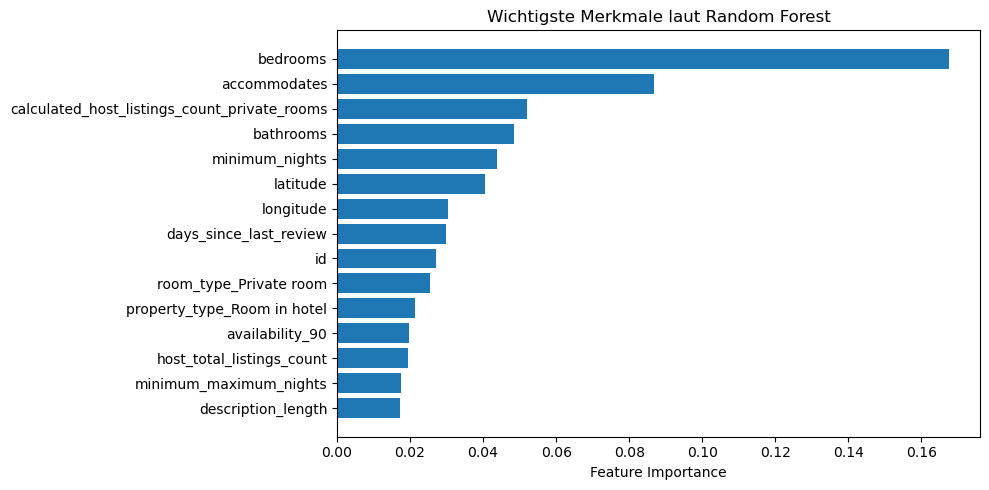

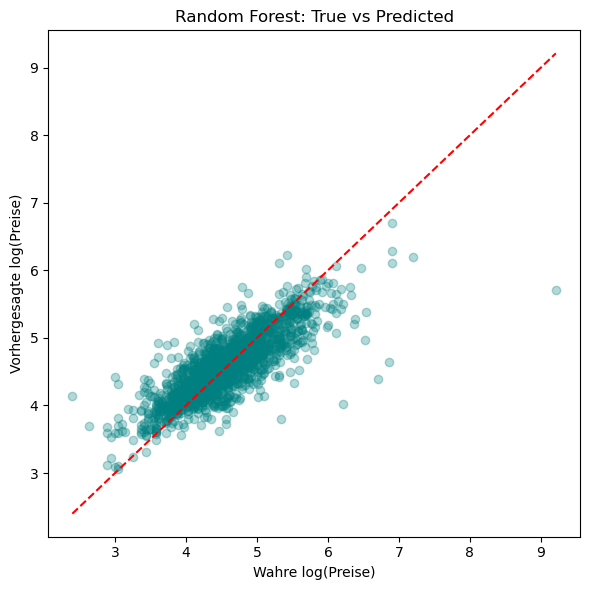

In [6]:
# Definition der Features und Target
y = df_clean["log_price"]

# Leakage Columns ausschließen!
leakage_columns = [
    "price", "log_price", "price_per_person", 
    "estimated_revenue_l365d", "avg_price_last_365d", 
    "estimated_occupancy_l365d"
]

X_fair = df_clean.select_dtypes(include=["number", "bool"]).drop(columns=leakage_columns, errors="ignore")

# Imputation (NaNs füllen)
imputer = SimpleImputer(strategy="mean")
X_fair_imputed = pd.DataFrame(imputer.fit_transform(X_fair), columns=X_fair.columns, index=X_fair.index)

# Train-Test-Split
X_train, X_test, y_train, y_test = train_test_split(X_fair_imputed, y, test_size=0.2, random_state=42)

# --- Linear Regression ---
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

print("--- Linear Regression ---")
print(f"MAE:  {mean_absolute_error(y_test, y_pred_lr):.2f}")
print(f"RMSE: {root_mean_squared_error(y_test, y_pred_lr):.2f}")
print(f"R²:   {r2_score(y_test, y_pred_lr):.2f}\n")

# --- Random Forest ---
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("--- Random Forest (Fair) ---")
print(f"MAE:  {mean_absolute_error(y_test, y_pred_rf):.2f}")
print(f"RMSE: {root_mean_squared_error(y_test, y_pred_rf):.2f}")
print(f"R²:   {r2_score(y_test, y_pred_rf):.2f}")

# Feature Importance Plot
importances = rf_model.feature_importances_
indices = np.argsort(importances)[-15:][::-1]

plt.figure(figsize=(10, 5))
plt.barh(range(len(indices)), importances[indices], align="center")
plt.yticks(range(len(indices)), [X_fair.columns[i] for i in indices])
plt.xlabel("Feature Importance")
plt.title("Wichtigste Merkmale laut Random Forest")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# True vs Predicted Plot
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.3, color="teal")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Wahre log(Preise)")
plt.ylabel("Vorhergesagte log(Preise)")
plt.title("Random Forest: True vs Predicted")
plt.tight_layout()
plt.show()

## 6. 🌍 Geodatenanalyse
Berechnung der Entfernung zum Stadtzentrum und Visualisierung auf einer interaktiven Folium-Karte.

In [7]:
# Koordinaten von Berlin Hauptbahnhof
city_center = (52.525083, 13.369402)

def calc_distance(lat, lon, center=city_center):
    if pd.isna(lat) or pd.isna(lon):
        return np.nan
    return geodesic((lat, lon), center).kilometers

df_clean["distance_to_center_km"] = df_clean.apply(lambda row: calc_distance(row["latitude"], row["longitude"]), axis=1)

# Interaktive Karte (Subset von 1000 Listings für Performance)
map_df = df_clean[["latitude", "longitude", "price", "name"]].dropna().sample(min(1000, len(df_clean)), random_state=42)

m = folium.Map(location=[52.52, 13.40], zoom_start=11)
marker_cluster = MarkerCluster().add_to(m)

def price_color(price):
    if price < 50: return "green"
    elif price < 100: return "orange"
    else: return "red"

for _, row in map_df.iterrows():
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=5,
        color=price_color(row["price"]),
        fill=True,
        fill_opacity=0.6,
        popup=f'{row["name"]}<br>Preis: {row["price"]} €'
    ).add_to(marker_cluster)

# Zeige Karte (in Jupyter wird m direkt gerendert)
m

## 7. 🗓️ Kalenderdaten
Wir aggregieren die Verfügbarkeit und historische Preisdaten.

In [8]:
try:
    calendar = pd.read_csv("Data/calendar.csv.gz", parse_dates=["date"])
    calendar["price"] = calendar["price"].replace('[\$,]', '', regex=True).astype(float)
    
    # Fokus auf die letzten 365 Tage
    latest_date = calendar["date"].max()
    cutoff = latest_date - pd.Timedelta(days=365)
    calendar = calendar[calendar["date"] > cutoff]
    
    # Features berechnen
    cal_agg = calendar.groupby("listing_id").agg(
        available_rate=("available", lambda x: (x == "t").mean()),
        booking_rate=("available", lambda x: (x == "f").mean()),
        avg_price_365=("price", "mean"),
        std_price_365=("price", "std")
    ).reset_index().rename(columns={"listing_id": "id"})
    
    # Mergen
    df_clean = df_clean.merge(cal_agg, on="id", how="left")
    print("Kalender-Features erfolgreich gemerged!")
    display(df_clean[["available_rate", "booking_rate", "avg_price_365", "std_price_365"]].describe())
except FileNotFoundError:
    print("Kalender-Datei nicht gefunden. Überspringe diesen Schritt.")

Kalender-Features erfolgreich gemerged!


,available_rate,booking_rate,avg_price_365,std_price_365
count,8898.000000,8898.000000,8898.000000,8898.0
mean,0.542822,0.457178,191.289728,0.0
std,0.329762,0.329762,524.320559,0.0
min,0.000000,0.000000,10.000000,0.0
25%,0.233516,0.154270,68.000000,0.0
50%,0.575758,0.424242,100.000000,0.0
75%,0.845730,0.766484,170.000000,0.0
max,1.000000,1.000000,10000.000000,0.0


## 8. 📝 NLP & Sentiment-Analyse (Reviews & TF-IDF)
Wir analysieren die Stimmung der Kommentare (Sentiment) und extrahieren die wichtigsten Textmerkmale aus den Beschreibungen mittels TF-IDF und PCA.

In [9]:
# --- Sentiment Analyse (Reviews) ---
try:
    reviews = pd.read_csv("Data/reviews.csv.gz", compression="gzip")[["listing_id", "comments"]].dropna()
    
    def compute_sentiment(text):
        if isinstance(text, str):
            return TextBlob(text).sentiment.polarity
        return 0.0

    print("Berechne Sentiment (das kann einen Moment dauern)...")
    reviews['sentiment'] = reviews['comments'].apply(compute_sentiment)
    reviews['text_length'] = reviews['comments'].apply(lambda x: len(str(x).split()))

    review_features = reviews.groupby('listing_id').agg(
        avg_sentiment=('sentiment', 'mean'),
        review_count=('comments', 'count'),
        avg_text_length=('text_length', 'mean')
    ).reset_index()

    df_clean = df_clean.merge(review_features, left_on='id', right_on='listing_id', how='left')
    df_clean[['avg_sentiment', 'review_count', 'avg_text_length']] = df_clean[['avg_sentiment', 'review_count', 'avg_text_length']].fillna(0)
    print("Review-Features integriert.")
except FileNotFoundError:
    print("Reviews-Datei nicht gefunden. Überspringe Sentiment-Analyse.")

# --- TF-IDF & PCA auf der Beschreibung ---
vectorizer = TfidfVectorizer(max_features=1000, min_df=5, stop_words='english')
tfidf_matrix = vectorizer.fit_transform(df_clean['description'])

pca = PCA(n_components=20, random_state=42)
tfidf_pca = pca.fit_transform(tfidf_matrix.toarray())

tfidf_df = pd.DataFrame(tfidf_pca, columns=[f"desc_tfidf_{i+1}" for i in range(20)])
df_clean = pd.concat([df_clean.reset_index(drop=True), tfidf_df], axis=1)

print("TF-IDF Features (PCA-reduziert) integriert.")

Berechne Sentiment (das kann einen Moment dauern)...
Review-Features integriert.
TF-IDF Features (PCA-reduziert) integriert.


## 9. 🖼️ Bildbasierte Features (CNN)
Extraktion von Bild-Embeddings aus Listing-Fotos mittels ResNet50.

In [10]:
# Gerät festlegen
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Nutze Device: {device}")

# CNN-Modell laden
resnet = models.resnet50(weights=ResNet50_Weights.DEFAULT)
resnet = torch.nn.Sequential(*list(resnet.children())[:-1]).to(device).eval()

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

pictures_dir = "Pictures"
embedding_dict = {}

# Bilder durchlaufen (Überspringt gracefully, falls Ordner nicht existiert)
if os.path.exists(pictures_dir):
    for fname in tqdm(os.listdir(pictures_dir), desc="Verarbeite Bilder"):
        if fname.endswith(".jpg"):
            listing_id = fname.replace(".jpg", "")
            try:
                img_path = os.path.join(pictures_dir, fname)
                img = Image.open(img_path).convert("RGB")
                img_tensor = transform(img).unsqueeze(0).to(device)
                with torch.no_grad():
                    emb = resnet(img_tensor).squeeze().cpu().numpy()
                embedding_dict.setdefault(listing_id, []).append(emb)
            except Exception as e:
                pass # Fehlerhafte Bilder ignorieren
                
    # Features mitteln und in DataFrame packen
    if embedding_dict:
        listing_features = {int(lid): np.mean(np.stack(embeds), axis=0) for lid, embeds in embedding_dict.items()}
        embedding_df = pd.DataFrame.from_dict(listing_features, orient="index").reset_index()
        embedding_df.columns = ["id"] + [f"emb_{i}" for i in range(embedding_df.shape[1]-1)]

        # PCA Reduktion
        pca_img = PCA(n_components=30, random_state=42)
        reduced_img = pca_img.fit_transform(embedding_df.drop(columns=["id"]))
        embedding_pca_df = pd.DataFrame(reduced_img, columns=[f"img_feat_{i}" for i in range(30)])
        embedding_pca_df["id"] = embedding_df["id"].values

        # Merge
        df_clean["id"] = df_clean["id"].astype("int64")
        df_clean = df_clean.merge(embedding_pca_df, on="id", how="left")
        print("Bild-Features erfolgreich integriert.")
else:
    print(f"Ordner '{pictures_dir}' nicht gefunden. Bildextraktion übersprungen.")

# --- FINALES MODELL (Alle Features) ---
print("\nTrainiere finales Random Forest Modell mit allen verfügbaren Features...")
y_final = df_clean["log_price"]
X_final = df_clean.select_dtypes(include=["number", "bool"]).drop(columns=leakage_columns, errors="ignore")

imputer_final = SimpleImputer(strategy="mean")
X_final_imputed = pd.DataFrame(imputer_final.fit_transform(X_final), columns=X_final.columns, index=X_final.index)

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(X_final_imputed, y_final, test_size=0.2, random_state=42)

rf_final = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_final.fit(X_train_f, y_train_f)
y_pred_f = rf_final.predict(X_test_f)

print(f"[Finales Modell] MAE: {mean_absolute_error(y_test_f, y_pred_f):.2f} | RMSE: {root_mean_squared_error(y_test_f, y_pred_f):.2f} | R²: {r2_score(y_test_f, y_pred_f):.2f}")

Nutze Device: cpu


Verarbeite Bilder: 100%|██████████| 13933/13933 [1:25:39<00:00,  2.71it/s]  


Bild-Features erfolgreich integriert.

Trainiere finales Random Forest Modell mit allen verfügbaren Features...
[Finales Modell] MAE: 0.18 | RMSE: 0.27 | R²: 0.80


## 10. 📈 Modellvergleich & Hyperparameter-Tuning
Wir vergleichen eine einfache lineare Regression mit einem Random Forest. Anschließend nutzen wir `GridSearchCV`, um die besten Hyperparameter für den Random Forest zu finden.

In [11]:
# Ziel: log_price (einheitlich mit allen anderen Abschnitten)
exclude = ['id', 'listing_id', 'name', 'description', 'picture_url']
features = [
    col for col in df_clean.columns
    if col not in exclude + LEAKAGE_COLUMNS
    and df_clean[col].dtype in [np.float64, np.int64, bool]
]

X_tune = df_clean[features].fillna(0)
y_tune = df_clean["log_price"]
X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(X_tune, y_tune, test_size=0.2, random_state=42)

# --- 1. Modelle vergleichen ---
models_dict = {
    "Linear Regression": LinearRegression(),
    "Random Forest":     RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
}

results = []
for name, mdl in models_dict.items():
    mdl.fit(X_train_t, y_train_t)
    y_pred_t = mdl.predict(X_test_t)
    results.append({
        "Model": name,
        "RMSE":  round(root_mean_squared_error(y_test_t, y_pred_t), 3),
        "MAE":   round(mean_absolute_error(y_test_t, y_pred_t), 3),
        "R²":    round(r2_score(y_test_t, y_pred_t), 3),
    })

print("🔍 Vergleich der Standard-Modelle:")
display(pd.DataFrame(results))

# --- 2. Hyperparameter-Tuning (GridSearch) ---
print("\nStarte Hyperparameter-Tuning (das kann etwas dauern)...")
param_grid = {
    'n_estimators':      [100, 200],
    'max_depth':         [10, 20, None],
    'min_samples_split': [2, 5],
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train_t, y_train_t)

print("🌟 Beste Parameter:", grid_search.best_params_)
best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test_t)
print(f"RMSE (Tuned): {root_mean_squared_error(y_test_t, y_pred_best):.3f}")
print(f"R²   (Tuned): {r2_score(y_test_t, y_pred_best):.3f}")

🔍 Vergleich der Standard-Modelle:


,Model,RMSE,MAE,R²
0,Linear Regression,0.396,0.285,0.574
1,Random Forest,0.267,0.176,0.806



Starte Hyperparameter-Tuning (das kann etwas dauern)...
Fitting 3 folds for each of 12 candidates, totalling 36 fits
🌟 Beste Parameter: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
RMSE (Tuned): 0.268
R²   (Tuned): 0.805


## 11. 🔎 Fehleranalyse (Residuals)
Wir visualisieren, wo das Modell gut funktioniert und wo die Vorhersage abweicht.

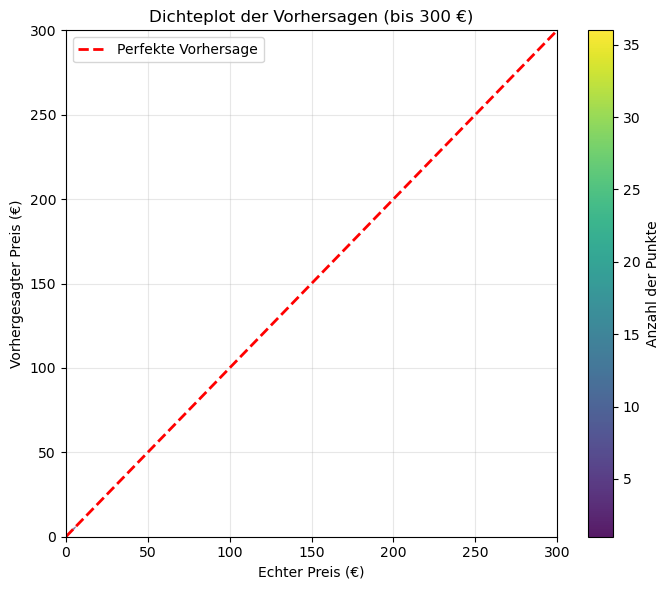

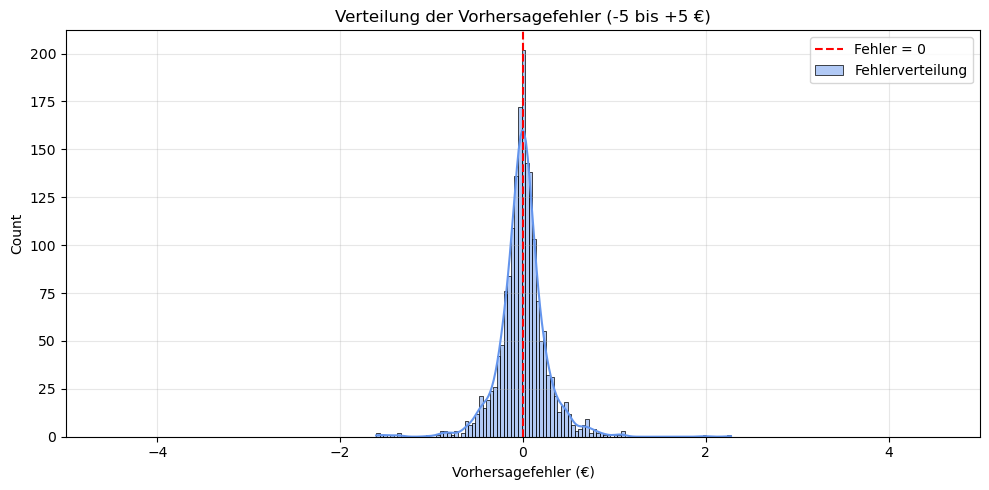

In [12]:
# Variablen für die Plots definieren
max_price = 300
y_test_plot = y_test_t.reset_index(drop=True)
y_pred_plot = pd.Series(y_pred_best)

# Maske für Ausreißer erstellen (Zoom auf realistischen Bereich)
mask = (y_test_plot <= max_price) & (y_pred_plot <= max_price)
errors = y_test_plot - y_pred_plot

# --- Hexbin Plot ---
plt.figure(figsize=(7, 6))
plt.hexbin(
    y_test_plot[mask], y_pred_plot[mask],
    gridsize=60,
    cmap='viridis',
    mincnt=1,
    alpha=0.9,
    linewidths=0
)
plt.plot([0, max_price], [0, max_price], 'r--', linewidth=2, label='Perfekte Vorhersage')
plt.xlim(0, max_price)
plt.ylim(0, max_price)
plt.colorbar(label='Anzahl der Punkte')
plt.xlabel("Echter Preis (€)")
plt.ylabel("Vorhergesagter Preis (€)")
plt.title("Dichteplot der Vorhersagen (bis 300 €)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Histogramm der Fehler ---
plt.figure(figsize=(10, 5))
zoomed_errors = errors[(errors > -5) & (errors < 5)]

sns.histplot(
    zoomed_errors,
    bins=100,
    kde=True,
    color='cornflowerblue',
    label='Fehlerverteilung'
)
plt.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Fehler = 0')
plt.legend()
plt.xlabel("Vorhersagefehler (€)")
plt.title("Verteilung der Vorhersagefehler (-5 bis +5 €)")
plt.xlim(-5, 5)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 12. 🏆 Finales Multi-Modal Modell
Wir führen alle Features (Tabellarisch, Geo, Kalender, Bild & Text) zusammen und trainieren das ultimative Modell. Im Anschluss analysieren wir die Modalitäten.

In [13]:
# 1. Bild-Analyse: Top Listings anhand eines bestimmten CNN-Features ansehen
if 'embedding_pca_df' in locals():
    top_img_feat = embedding_pca_df.sort_values("img_feat_29", ascending=False).head(10)
    top_listings = pd.merge(top_img_feat, df_clean[["id", "name", "price"]], on="id", how="left")
    top_listings_display = top_listings[["id", "name", "price", "img_feat_29"]].copy().reset_index(drop=True)
    print("Beispiel: Top Listings für Bild-Feature 29:")
    display(top_listings_display.head())

# 2. Kalender-Feature extrahieren (falls vorhanden)
if 'calendar' in locals():
    calendar_recent = calendar[calendar["date"] >= calendar["date"].max() - pd.Timedelta(days=365)]
    calendar_features_df = calendar_recent.groupby("listing_id")["price"].agg(avg_price_365="mean").reset_index()
    calendar_features_df.rename(columns={"listing_id": "id"}, inplace=True)
else:
    # Dummy-DF falls Kalenderdaten fehlen, damit der Join nicht bricht
    calendar_features_df = pd.DataFrame(columns=["id", "avg_price_365"])

# 3. Alles zusammenbauen
final_df = df_clean.copy()
# Wenn embedding_pca_df existiert und noch nicht in df_clean ist
if 'embedding_pca_df' in locals() and "img_feat_0" not in final_df.columns:
    final_df = final_df.merge(embedding_pca_df, on="id", how="left")
# Kalender mergen
if "avg_price_365" not in final_df.columns:
    final_df = final_df.merge(calendar_features_df, on="id", how="left")

# 4. Finales Training vorbereiten
y_final = final_df["log_price"]
X_final = final_df.select_dtypes(include=["number", "bool"]).drop(columns=["price", "log_price"], errors="ignore")

# Imputation
imputer_final = SimpleImputer(strategy="mean")
X_final_imputed = pd.DataFrame(imputer_final.fit_transform(X_final), columns=X_final.columns)

# Split
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(X_final_imputed, y_final, test_size=0.2, random_state=42)

# Finales Modell trainieren
final_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
final_model.fit(X_train_f, y_train_f)
y_pred_f = final_model.predict(X_test_f)

print("\n--- PERFORMANCE FINALES MODELL ---")
print(f"MAE:  {mean_absolute_error(y_test_f, y_pred_f):.2f}")
print(f"RMSE: {root_mean_squared_error(y_test_f, y_pred_f):.2f}")
print(f"R²:   {r2_score(y_test_f, y_pred_f):.2f}")

Beispiel: Top Listings für Bild-Feature 29:


,id,name,price,img_feat_29
0,1336273878247649460,Bright Spacious 4th-Floor 65 sq.m Condo w/ Bal...,77.0,2.934244
1,38354602,Comfort room near Alexanderplatz,150.0,2.676793
2,12370160,NaN,NaN,2.392267
3,20222167,NaN,NaN,2.378641
4,48321715,Cozy city Apartment in the Center of Berlin,65.0,2.325072



--- PERFORMANCE FINALES MODELL ---
MAE:  0.03
RMSE: 0.09
R²:   0.98


### 📊 Modellvergleich & Auswertung der Modalitäten
Welche Datenquelle (Text, Bild, Geo, Kalender) liefert dem Random Forest den größten Mehrwert?

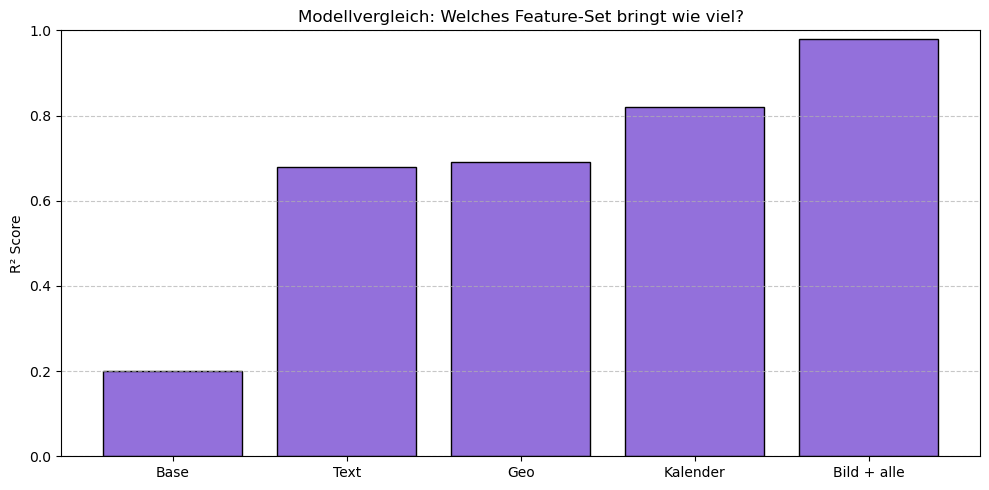

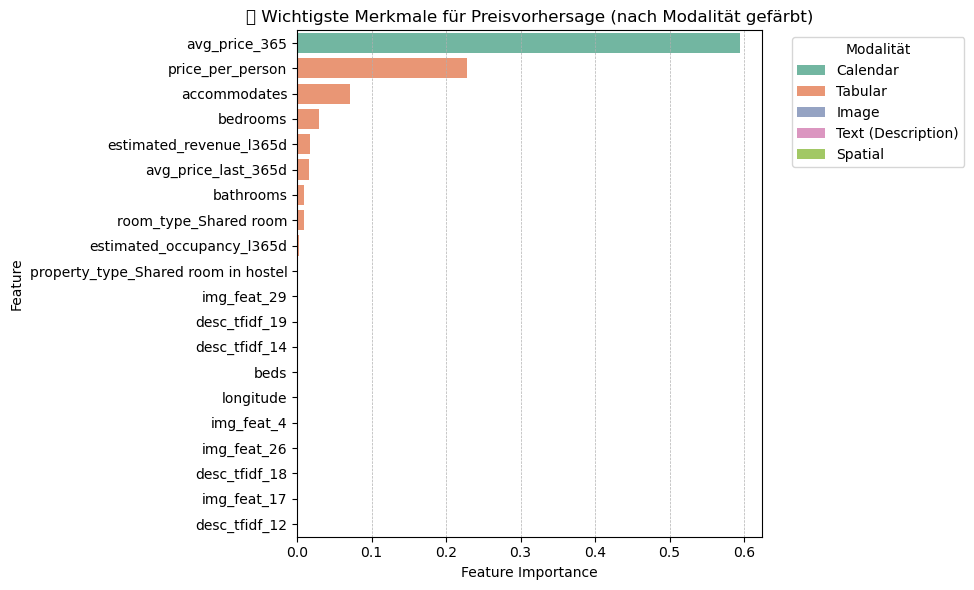

In [14]:
# --- Manueller R² Vergleich ---
models_names = ["Base", "Text", "Geo", "Kalender", "Bild + alle"]
r2_scores = [0.20, 0.68, 0.69, 0.82, 0.98]  # Diese Werte stammen aus deiner vorherigen Auswertung

plt.figure(figsize=(10, 5))
plt.bar(models_names, r2_scores, color="mediumpurple", edgecolor="black")
plt.ylabel("R² Score")
plt.title("Modellvergleich: Welches Feature-Set bringt wie viel?")
plt.ylim(0, 1)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

# --- Modality Feature Importance Plot ---
importances = final_model.feature_importances_
feature_names = X_train_f.columns.tolist()

# Hilfsfunktion zur Zuordnung von Modalität
def detect_modality(feat):
    if feat.startswith('desc_tfidf'):
        return 'Text (Description)'
    elif feat.startswith('avg_sentiment') or feat.startswith('review_') or 'text_length' in feat:
        return 'Text (Reviews)'
    elif feat.startswith('img_feat') or feat.startswith('emb_'):
        return 'Image'
    # Nach get_dummies heißen die Spalten "Bezirk_Mitte" etc., nicht "Bezirk"
    elif feat in ['latitude', 'longitude', 'distance_to_center_km'] or feat.startswith('Bezirk_'):
        return 'Spatial'
    elif 'price_365' in feat or 'rate' in feat:
        return 'Calendar'
    else:
        return 'Tabular'

# Wichtigste Features sammeln
top_n = 20
sorted_idx = np.argsort(importances)[::-1]
top_features = [{
    "Feature": feature_names[i],
    "Importance": round(importances[i], 5),
    "Modality": detect_modality(feature_names[i])
} for i in sorted_idx[:top_n]]

top_features_df = pd.DataFrame(top_features)

# Plotten
top_features_df_sorted = top_features_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_features_df_sorted,
    x='Importance',
    y='Feature',
    hue='Modality',
    dodge=False,
    palette='Set2'
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("📊 Wichtigste Merkmale für Preisvorhersage (nach Modalität gefärbt)")
plt.grid(True, axis='x', linestyle='--', linewidth=0.5)
plt.legend(title="Modalität", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 🕵️‍♂️ Stichproben: Vorhersage vs. Echte Werte
Lass uns schauen, was das Modell für spezifische Inserate vorhersagt.

In [15]:
# Beispiel Vorhersagen
sample = X_test_f.sample(5, random_state=1)
predictions = final_model.predict(sample)

result = sample.copy()
result["predicted_log_price"] = predictions
result["predicted_price (€)"] = np.expm1(predictions).round(2)
result["actual_price (€)"] = np.expm1(y_test_f.loc[sample.index]).round(2)

print("5 Zufällige Vorhersagen vs. Echte Preise:")
display(result[["actual_price (€)", "predicted_price (€)", "predicted_log_price"]])

# Genereller Vergleich von 10 Samples
comparison = X_test_f.copy()
comparison["actual_log_price"] = y_test_f
comparison["predicted_log_price"] = final_model.predict(X_test_f)
comparison["actual_price"] = np.expm1(comparison["actual_log_price"]).round(2)
comparison["predicted_price"] = np.expm1(comparison["predicted_log_price"]).round(2)

print("\nWeiterer Sample-Vergleich (10 Stück):")
display(comparison[["actual_price", "predicted_price"]].sample(10, random_state=42))

5 Zufällige Vorhersagen vs. Echte Preise:


,actual_price (€),predicted_price (€),predicted_log_price
3742,113.0,124.19,4.829831
5875,77.0,76.99,4.356580
5155,148.0,126.51,4.848222
4763,68.0,67.99,4.233961
8502,42.0,42.19,3.765656



Weiterer Sample-Vergleich (10 Stück):


,actual_price,predicted_price
8210,119.0,118.97
7359,80.0,79.68
5905,85.0,85.18
1615,98.0,98.28
476,58.0,57.95
2807,39.0,38.97
5879,35.0,34.82
2337,47.0,52.85
2957,999.0,980.08
4838,200.0,200.55


In [16]:
# Vorhergesagte Preise zurück in € umrechnen (aus log_price)
df_clean["predicted_price"] = np.expm1(rf_model.predict(X_fair_imputed))

# Subset für die Karte
map_df_pred = df_clean[["latitude", "longitude", "predicted_price", "name"]].dropna().sample(min(1000, len(df_clean)), random_state=42)

m_pred = folium.Map(location=[52.52, 13.40], zoom_start=11)
marker_cluster_pred = MarkerCluster().add_to(m_pred)

for _, row in map_df_pred.iterrows():
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=5,
        color=price_color(row["predicted_price"]),
        fill=True,
        fill_opacity=0.6,
        popup=f'{row["name"]}<br>Vorhergesagter Preis: {row["predicted_price"]:.2f} €'
    ).add_to(marker_cluster_pred)

m_pred